# Building a rotation gate from a starting state and a target state

Given any single-qubit states $|\psi\rangle$ (start) and $|\phi\rangle$ (target), find a gate $U$ with $U|\psi\rangle = |\phi\rangle$.

## The outer-product recipe

The outer product $|\phi\rangle\langle\psi|$ sends $|\psi\rangle$ to $|\phi\rangle$ and everything orthogonal to $|\psi\rangle$ to zero. That alone is not unitary, so we add the same thing for the orthogonal pair:

$$U = |\phi\rangle\langle\psi| + |\phi_\perp\rangle\langle\psi_\perp|$$

For a state $|s\rangle = (a, b)$, the orthogonal state is $|s_\perp\rangle = (-\bar b, \bar a)$. Then $U$ is unitary and rotates the whole Bloch sphere so that $\psi$ lands on $\phi$.

A handy view: let $P_s = |s\rangle\langle 0| + |s_\perp\rangle\langle 1|$ be the gate that prepares $|s\rangle$ from $|0\rangle$. Then $U = P_\phi P_\psi^\dagger$: "undo $\psi$, then prepare $\phi$".

## How we check it

We cannot read a state directly, so we *uncompute*:

$$|0\rangle \xrightarrow{P_\psi} |\psi\rangle \xrightarrow{U} |\phi\rangle \xrightarrow{P_\phi^\dagger} |0\rangle$$

If $U$ is right we measure 0 every time. As a control we skip $U$: then we measure 0 only with probability $|\langle\phi|\psi\rangle|^2$, which is less than 1.

## The steps

Every example in this folder follows the same recipe:

1. **Circuit**: build the abstract circuit.
2. **Transpile**: rewrite it into the gates and qubits the backend supports (an "ISA circuit").
3. **Observable**: what to measure (Estimator only).
4. **PUB**: bundle what to run (a Primitive Unified Bloc, a tuple that starts with the circuit).
5. **Execute**: hand the PUBs to a primitive and wait for the job.
6. **Read**: turn the raw result into numbers and compare with theory.

## Setup

By default this notebook runs only on the noiseless Aer simulator. To also run on IBM hardware, set `skip_hardware=False` below (you need a saved token; see `00-Setup-Start-Here`). Hardware jobs may wait in a queue.

In [1]:
import sys
from pathlib import Path
from types import SimpleNamespace

import numpy as np
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# _runtime.py (in ../scripts) only decides *where* to run: Aer and/or IBM hardware.
sys.path.insert(0, str(Path.cwd().parent / "scripts"))
from _runtime import get_targets

np.set_printoptions(precision=3, suppress=True)

SETTINGS = SimpleNamespace(
    shots=4096,                  # shots per circuit (Sampler jobs)
    precision=0.02,              # target standard error (Estimator jobs)
    backend="ibm_rensselaer",
    name="default",              # saved IBM account name
    skip_hardware=True,          # set to False to also run on IBM hardware
    poll_interval=20,
)
targets = get_targets(SETTINGS)
print("Running on:", [t.label for t in targets])

Running on: ['aer']


## The math (exact)

In [2]:
def bloch_state(theta, phi):
    """cos(theta/2)|0> + e^(i phi) sin(theta/2)|1>"""
    return np.array([np.cos(theta / 2), np.exp(1j * phi) * np.sin(theta / 2)])


def orthogonal(state):
    """(a, b) -> (-conj(b), conj(a))"""
    return np.array([-np.conj(state[1]), np.conj(state[0])])


def prepare_matrix(state):
    """P_s = |s><0| + |s_perp><1|, which maps |0> to |s>."""
    return np.outer(state, [1, 0]) + np.outer(orthogonal(state), [0, 1])


def rotation_matrix(start, target):
    """U = |target><start| + |target_perp><start_perp|"""
    return np.outer(target, start.conj()) + np.outer(
        orthogonal(target), orthogonal(start).conj()
    )


plus = bloch_state(np.pi / 2, 0)
minus_i = bloch_state(np.pi / 2, -np.pi / 2)
cases = {
    "|0> -> |+>": (bloch_state(0, 0), plus),
    "|+> -> |-i>": (plus, minus_i),
    "generic": (bloch_state(1.0, 0.5), bloch_state(2.2, -1.3)),
}

for case, (start, target) in cases.items():
    u = rotation_matrix(start, target)
    print(f"{case:12s} unitary: {np.allclose(u.conj().T @ u, np.eye(2))}"
          f"   U|psi> == |phi>: {np.allclose(u @ start, target)}")

|0> -> |+>   unitary: True   U|psi> == |phi>: True
|+> -> |-i>  unitary: True   U|psi> == |phi>: True
generic      unitary: True   U|psi> == |phi>: True


## Step 1: Circuits

For each case we build the uncompute circuit twice: once with $U$ and once without (the control). The barriers keep the transpiler from merging the pieces.

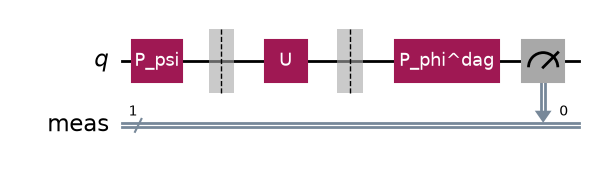

In [3]:
from qiskit.circuit.library import UnitaryGate


def build_circuit(start, target, rotate):
    qubits = QuantumRegister(1, name="q")
    bits = ClassicalRegister(1, name="meas")
    circuit = QuantumCircuit(qubits, bits, name="with_U" if rotate else "no_U")
    circuit.append(UnitaryGate(prepare_matrix(start), label="P_psi"), qubits)
    circuit.barrier()
    if rotate:
        circuit.append(UnitaryGate(rotation_matrix(start, target), label="U"), qubits)
        circuit.barrier()
    circuit.append(UnitaryGate(prepare_matrix(target).conj().T, label="P_phi^dag"), qubits)
    circuit.measure(qubits, bits)
    return circuit


circuits, expected_p0 = {}, {}
for case, (start, target) in cases.items():
    circuits[f"{case} with U"] = build_circuit(start, target, rotate=True)
    circuits[f"{case} no U"] = build_circuit(start, target, rotate=False)
    expected_p0[f"{case} with U"] = 1.0
    expected_p0[f"{case} no U"] = abs(np.vdot(target, start)) ** 2

circuits["|0> -> |+> with U"].draw("mpl")

## Step 2: Transpile

An arbitrary 2x2 unitary is not a native gate. The transpiler decomposes each one into the backend's basis gates (Aer: `u3`; IBM chips: `rz`, `sx`, and `x`), so one `UnitaryGate` becomes a few real gates.

In [4]:
isa_circuits = {}
for target in targets:
    pass_manager = generate_preset_pass_manager(backend=target.backend, optimization_level=1)
    isa_circuits[target.label] = {n: pass_manager.run(c) for n, c in circuits.items()}
    print(target.label, "-> 'generic with U' became:",
          dict(isa_circuits[target.label]["generic with U"].count_ops()))

aer -> 'generic with U' became: {'u3': 3, 'barrier': 2, 'measure': 1}


## Step 3: Observable

Not needed (Sampler).

## Step 4: PUBs

In [5]:
pubs = {label: [(isa,) for isa in group.values()] for label, group in isa_circuits.items()}

## Step 5: Execute

In [6]:
results = {}
for target in targets:
    job = target.sampler.run(pubs[target.label], shots=SETTINGS.shots)
    results[target.label] = target.wait(job)

## Step 6: Read the results

In [7]:
for label, result in results.items():
    if result is None:
        continue
    print(f"P(0) from {SETTINGS.shots} shots on {label}:")
    for name, pub_result in zip(circuits, result):
        counts = pub_result.data.meas.get_counts()
        p0 = counts.get("0", 0) / SETTINGS.shots
        print(f"  {name:22s} P(0) = {p0:.3f}   ideal = {expected_p0[name]:.3f}")

P(0) from 4096 shots on aer:
  |0> -> |+> with U      P(0) = 1.000   ideal = 1.000
  |0> -> |+> no U        P(0) = 0.496   ideal = 0.500
  |+> -> |-i> with U     P(0) = 1.000   ideal = 1.000
  |+> -> |-i> no U       P(0) = 0.509   ideal = 0.500
  generic with U         P(0) = 1.000   ideal = 1.000
  generic no U           P(0) = 0.263   ideal = 0.264


## Takeaway

With $U$ the qubit always returns to 0, so the rotation worked. Without it, $P(0) = |\langle\phi|\psi\rangle|^2$.